# Desktop adjustment ladder — August 2026 (anchor 2026-07-28)

**Purpose:** see exactly what each adjustment does to the desktop 28-day-MA curve, one at a time.
Desktop (`legacy_desktop` DAU) only. Nothing here is a forecast deliverable — it is a diagnostic.

## The two kinds of adjustment behave completely differently

This is the thing to internalise before reading the plots.

| | codes | where it is applied | can a notebook toggle it? |
|---|---|---|---|
| **Per-tile bidirectional** | `l` launch-on-login, `o` MozillaOnline | *inside* the model — subtracted from `modern_windows` training rows **before** mozaic, then added back to the forecast | **No.** Baked into the parquet. Isolating one needs its own model run. |
| **Display-layer** | `h` Win10 headwind | *after* the model — added to the finished 28-day MA | **Yes.** Free to toggle, and its effect is exact arithmetic. |

Because `l` and `o` change the training frame, they are **not simply additive**: the model refits around
the modified history, so the effect of `l`+`o` together need not equal the effect of `l` plus the effect
of `o`. The tables below measure that directly.

To make the `l`/`o` ladder possible, four separate desktop forecasts were run at the same anchor, same
data, same locked parameters, differing only in which overlays were active:

| run | overlays | artifact |
|---|---|---|
| A | none | `adjustment_isolation/none/…ld-D.raw.parquet` |
| B | `l` only | `adjustment_isolation/l_only/…ld-D.adj-l.parquet` |
| C | `o` only | `adjustment_isolation/o_only/…ld-D.adj-o.parquet` |
| D | `l` + `o` | `desktop_baseline_2026-07-28/…ld-D.adj-lo.parquet` (the canonical build) |

`h` is then layered on top of D at the display layer, under two competing conventions — see
`[plot-headwind-conventions]`, which is the plot that explains the seam discontinuity.

## What each adjustment is

- **`l` launch-on-login** — tailwind. Firefox launches at OS login for new modern-Windows installs
  (100% rollout 2026-05-08). Curve rises on measurement to 130,296 at 2026-06-23, then extrapolates to a
  flat **180,000/day** ceiling from 2026-07-12. Modern-Windows only.
- **`o` MozillaOnline** — tailwind. China distribution partner migrating users onto mainline Firefox;
  they flip `app_name` and newly count as Firefox Desktop. Peaks ~724K/day late July, churn-declines to
  ~607K by Dec-15. Modern-Windows only, fixed geo shares (CN ~93%).
- **`h` Win10 headwind** — headwind. Linear ramp from zero at **2026-04-01** to **−1,245,000** at the
  **2026-12-15** anchor. Represents Win10-migration attrition the model has not learned on its own.


In [1]:
# [setup]
import os
import json
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from google.cloud import bigquery

os.chdir(subprocess.run(['git', 'rev-parse', '--show-toplevel'],
                        capture_output=True, text=True).stdout.strip())
import sys
sys.path.insert(0, "src")
# The variance-matched seam MA now lives in the package: src/mozaic_daily/seam_ma.py. Cycles
# through 2026-07 import a frozen copy from data-official/2026-06/ so their delivered curves
# cannot move; new work imports from the package. seam_ma carries the A1 trend-estimator fix
# (deseasonalize before averaging) -- see research/ma-seam-turbulence/LOG.md, Fix A.
from mozaic_daily.seam_ma import display_ma  # noqa: E402
from mozaic_daily.adjustments import load_forecast         # noqa: E402

# --- The four desktop runs -------------------------------------------------------------------------
# Same anchor, same data, same locked params (cps=0.08983, cpr=0.65, ncp=25, recent=13,
# threshold=-0.032). ONLY the active overlays differ. Runs A-C were produced by
# scripts/run_param_scan.py with the --no-launch-on-login / --no-mozillaonline toggles; run D is the
# canonical August build. Each parquet's filename marker states what is baked into it, and
# load_forecast(require_state=...) enforces that -- so a mislabelled run fails here, loudly.
SLUG = "cps0.08983_thresh032_recent13_cpr0.65_ncp25_clip0.6_sps0.00825"
ISO = "data-official/2026-08/adjustment_isolation"
RUNS = {
    "none": (f"{ISO}/none/{SLUG}/mozaic_daily_forecast.2026-07-28.ld-D.raw.parquet", []),
    "l":    (f"{ISO}/l_only/{SLUG}/mozaic_daily_forecast.2026-07-28.ld-D.adj-l.parquet", ["l"]),
    "o":    (f"{ISO}/o_only/{SLUG}/mozaic_daily_forecast.2026-07-28.ld-D.adj-o.parquet", ["o"]),
    "lo":   (f"data-official/2026-08/desktop_baseline_2026-07-28/{SLUG}/"
             f"mozaic_daily_forecast.2026-07-28.ld-D.adj-lo.parquet", ["l", "o"]),
}

HEADWIND_SPEC = "data-official/2026-08/adjustments/headwind.json"
PLOTS_DIR = "data-official/2026-08/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# --- Dates ------------------------------------------------------------------------------------------
SEAM = pd.Timestamp("2026-07-28")            # forecast_start; training ran through 2026-07-27
DISPLAY_START = pd.Timestamp("2026-01-01")
DISPLAY_END = pd.Timestamp("2026-12-31")
MEASUREMENT_DATE = pd.Timestamp("2026-12-15")  # the reported KPI date
TROUGH_DATE = pd.Timestamp("2026-08-22")       # near-horizon summer-trough reference
OCT1 = pd.Timestamp("2026-10-01")              # end of the window we want to lift
ZOOM = (pd.Timestamp("2026-06-01"), pd.Timestamp("2026-10-15"))  # seam-detail window
BQ_START = "2025-12-04"                        # 28d of lead-in before DISPLAY_START for the MA

# Consistent colours for the ladder, dark -> light as overlays accumulate.
COLORS = {"none": "#4C4C4C", "l": "#1F77B4", "o": "#2CA02C", "lo": "#9467BD"}
LABELS = {"none": "A: no overlays (raw model)", "l": "B: + l (launch-on-login)",
          "o": "C: + o (MozillaOnline)", "lo": "D: + l + o (canonical)"}

print(f"seam {SEAM.date()} | KPI {MEASUREMENT_DATE.date()} | trough ref {TROUGH_DATE.date()}")
print(f"headwind spec: {json.load(open(HEADWIND_SPEC))}")


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


seam 2026-07-28 | KPI 2026-12-15 | trough ref 2026-08-22
headwind spec: {'type': 'linear_ramp', 'start_date': '2026-07-28', 'anchor_date': '2026-12-15', 'desktop_dau': -1245000, 'mobile_dau': -27162}


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# [helpers]

def world_daily_dau(path, require_state):
    """World(ALL) daily desktop DAU from a validated forecast parquet."""
    df, meta = load_forecast(path, require_state=require_state)
    mask = (
        (df["country"] == "ALL")
        & (df["segment"] == '{"os": "ALL"}')
        & (df["data_source"] == "legacy_desktop")
        & (df["app_name"] == "desktop")
    )
    out = df.loc[mask, ["target_date", "dau", "data_type"]].copy()
    out["target_date"] = pd.to_datetime(out["target_date"])
    return out.sort_values("target_date").reset_index(drop=True), meta


def daily_to_28ma(dates, values):
    """Plain 28-day trailing MA. Used for actuals."""
    s = pd.Series(np.asarray(values), index=pd.to_datetime(np.asarray(dates)))
    return s.sort_index().rolling(28).mean()


def millions(x, pos=None):
    # Two decimals: the curves here sit within ~1M of each other, so a whole-million
    # formatter would render 48.52M and 48.67M as the same "49M".
    return f"{x / 1e6:.2f}M"


# --- Headwind ramp, under the two competing conventions ---------------------------------------------
# Both reach EXACTLY the same value at the Dec-15 anchor. They differ only in where the ramp starts,
# i.e. in how much of the ramp has already elapsed by the time it is switched on at the seam.

def headwind_ramp(index, *, ramp_start, applied_from, spec_path=HEADWIND_SPEC, platform="desktop"):
    """Linear headwind ramp as a date-indexed Series, zero before ``applied_from``.

    ramp_start   -- date the ramp leaves zero. The spec says 2026-04-01 ("as-applied"); passing the
                    seam instead gives the "seam-anchored" alternative.
    applied_from -- date the adjustment starts being added at all. Always the seam: history is
                    actuals and must never be moved retroactively.

    The anchor value is hit at spec["anchor_date"] under either convention, so switching conventions
    changes the whole interior of the curve while leaving the reported Dec-15 KPI untouched.
    """
    spec = json.load(open(spec_path))
    anchor_date = pd.Timestamp(spec["anchor_date"])
    amplitude = float(spec[f"{platform}_dau"])
    ramp_start = pd.Timestamp(ramp_start)
    total_days = (anchor_date - ramp_start).days
    idx = pd.DatetimeIndex(index)
    elapsed = np.maximum(0, (idx - ramp_start).days)
    ramp = pd.Series(amplitude * elapsed / total_days, index=idx)
    return ramp.where(idx >= pd.Timestamp(applied_from), 0.0)


def clip_to(s, lo, hi):
    return s[(s.index >= lo) & (s.index <= hi)].dropna()


def at(s, date):
    """Value of a date-indexed series at ``date``, NaN if absent."""
    return s.get(pd.Timestamp(date), np.nan)


In [3]:
# [load]
# Load the four runs and build their 28d-MA curves. Forecast curves use the variance-matched display_ma
# (seam-smoothed, same as the canonical notebook) so anything seen here is comparable to the published
# charts rather than an artefact of a different MA convention.
curves, metas = {}, {}
for key, (path, state) in RUNS.items():
    daily, meta = world_daily_dau(path, state)
    curves[key] = display_ma(daily["target_date"], daily["dau"], SEAM)
    metas[key] = meta
    last_train = daily.loc[daily["data_type"] == "training", "target_date"].max()
    print(f"{key:<5s} {os.path.basename(path):<52s} rows={len(daily):<5d} last_train={last_train.date()}")

# All four runs must share the locked config -- otherwise a difference between them could be a
# parameter difference rather than an overlay effect, and the whole ladder is meaningless.
base_config = metas["lo"]["model_config"]
for key, meta in metas.items():
    assert meta["model_config"] == base_config, (
        f"run '{key}' has a different model_config than the canonical run; the ladder would be "
        f"comparing parameters, not overlays. Diff: "
        f"{ {k: (v, base_config.get(k)) for k, v in meta['model_config'].items() if base_config.get(k) != v} }"
    )
    assert meta["forecast_start_date"] == "2026-07-28", f"run '{key}' has the wrong anchor"
print(f"\nAll 4 runs share the locked config and the 2026-07-28 anchor "
      f"({len(base_config)} params checked).")

# Actuals. Cutoff CURRENT_DATE("America/Los_Angeles") - 2: the most recent landed day can be partial,
# and one partial day drags the trailing-MA endpoint down by ~1M. Legacy telemetry, all countries.
client = bigquery.Client(project="moz-fx-data-bq-data-science")
actual_daily = client.query(f"""
    SELECT submission_date AS date, SUM(dau) AS dau
    FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
    WHERE app_name = "Firefox Desktop"
      AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE("America/Los_Angeles") - 2
    GROUP BY submission_date ORDER BY 1
""").to_dataframe()
actual_ma = daily_to_28ma(actual_daily["date"], actual_daily["dau"])
print(f"actuals: {len(actual_daily)} days through {pd.to_datetime(actual_daily['date']).max().date()}")


none  mozaic_daily_forecast.2026-07-28.ld-D.raw.parquet    rows=2922  last_train=2026-07-27


l     mozaic_daily_forecast.2026-07-28.ld-D.adj-l.parquet  rows=2922  last_train=2026-07-27
o     mozaic_daily_forecast.2026-07-28.ld-D.adj-o.parquet  rows=2922  last_train=2026-07-27


lo    mozaic_daily_forecast.2026-07-28.ld-D.adj-lo.parquet rows=2922  last_train=2026-07-27

All 4 runs share the locked config and the 2026-07-28 anchor (10 params checked).


actuals: 236 days through 2026-07-27


saved: data-official/2026-08/plots/ladder_00_raw.png


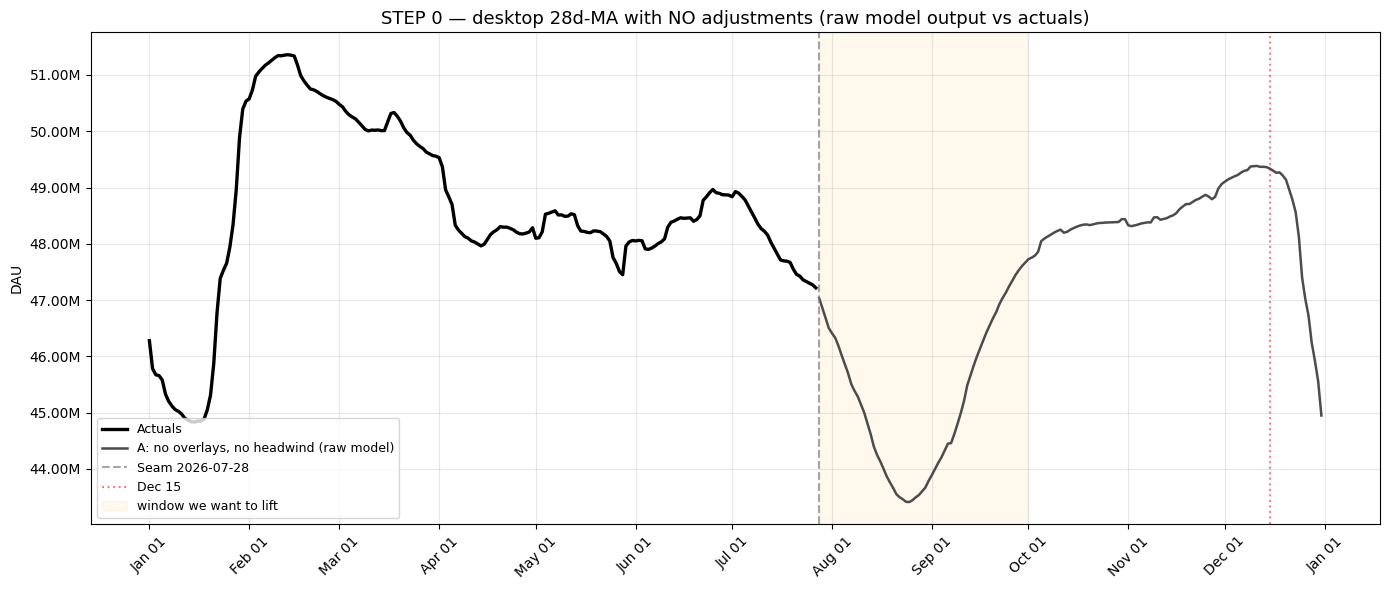

  none  seam step 2026-07-27 -> 2026-07-28: -179,991
  l     seam step 2026-07-27 -> 2026-07-28: -173,699
  o     seam step 2026-07-27 -> 2026-07-28: -159,103
  lo    seam step 2026-07-27 -> 2026-07-28: -153,185

All four runs are continuous across the seam -- none of them produces the drop seen in the published chart. Keep this in mind through STEP 3.

Raw-model summer trough: 43,412,085 on 2026-08-25


In [4]:
# [plot-raw]
# STEP 0 -- the model with NO adjustments of any kind. This is the honest starting point: Prophet's own
# view of 2026 desktop DAU, fit on training data through 2026-07-27.
#
# Two things to look for:
#   1. The summer trough is the MODEL's, not an artefact of any adjustment. Whatever we do with overlays,
#      this dip is what the parameter search would have to move.
#   2. The curve is CONTINUOUS across the seam. Note the printed step below -- there is no discontinuity
#      in the raw model output, which is what makes the seam drop in the published chart attributable
#      entirely to something applied afterwards.
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(clip_to(actual_ma, DISPLAY_START, DISPLAY_END), color="black", linewidth=2.4, label="Actuals")
ax.plot(clip_to(curves["none"], SEAM, DISPLAY_END), color=COLORS["none"], linewidth=1.8,
        label="A: no overlays, no headwind (raw model)")
ax.axvline(SEAM, color="grey", linestyle="--", alpha=0.7, label=f"Seam {SEAM.date()}")
ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
ax.axvspan(SEAM, OCT1, color="orange", alpha=0.07, label="window we want to lift")
ax.set_title("STEP 0 — desktop 28d-MA with NO adjustments (raw model output vs actuals)", fontsize=13)
ax.set_ylabel("DAU")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.legend(loc="lower left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
out = f"{PLOTS_DIR}/ladder_00_raw.png"
fig.savefig(out, dpi=130); print(f"saved: {out}")
plt.show()

prev = SEAM - pd.Timedelta(days=1)
for key in RUNS:
    step = at(curves[key], SEAM) - at(curves[key], prev)
    print(f"  {key:<5s} seam step {prev.date()} -> {SEAM.date()}: {step:+,.0f}")
print("\nAll four runs are continuous across the seam -- none of them produces the drop seen in the "
      "published chart. Keep this in mind through STEP 3.")
trough_val = clip_to(curves["none"], SEAM, DISPLAY_END).min()
trough_at = clip_to(curves["none"], SEAM, DISPLAY_END).idxmin()
print(f"\nRaw-model summer trough: {trough_val:,.0f} on {trough_at.date()}")


saved: data-official/2026-08/plots/ladder_01_overlays.png


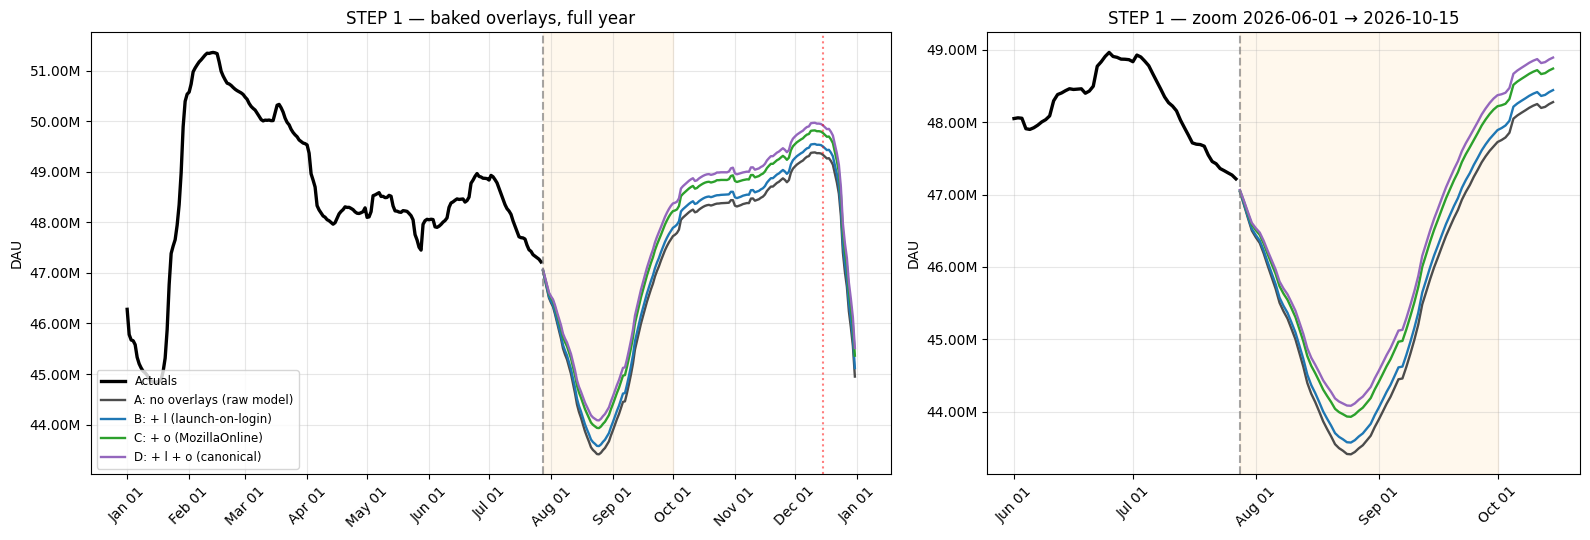

saved: data-official/2026-08/plots/ladder_01b_overlay_effects.png


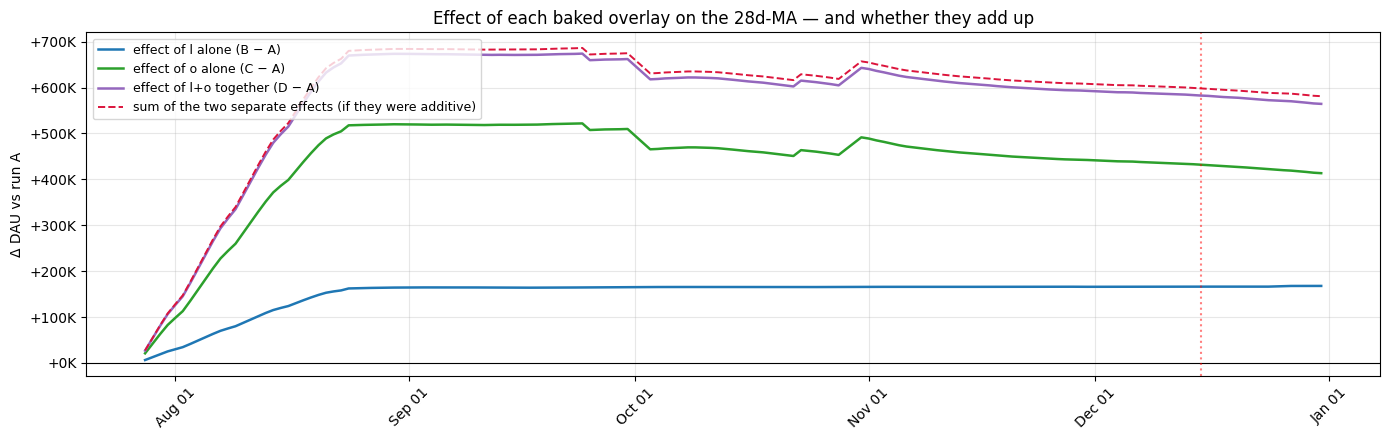

Where the dashed crimson line departs from the purple line, the two overlays are NOT additive — each one changed the training frame the other was fit against.


In [5]:
# [plot-overlay-ladder]
# STEP 1 -- the two BAKED-IN tailwinds, added one at a time. Four separate model runs; each line is its
# own Prophet fit, not an arithmetic shift of the line below it. That is the point: because `l` and `o`
# are subtracted from training before mozaic and added back after, the model refits around a modified
# history, so these curves can differ in SHAPE as well as level.
#
# Left panel: the full display year. Right panel: zoomed on the seam and the summer window, where the
# shape differences are visible.
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={"width_ratios": [1.35, 1]})

for ax, (lo_x, hi_x), title in [
    (axes[0], (DISPLAY_START, DISPLAY_END), "STEP 1 — baked overlays, full year"),
    (axes[1], ZOOM, f"STEP 1 — zoom {ZOOM[0].date()} → {ZOOM[1].date()}"),
]:
    ax.plot(clip_to(actual_ma, lo_x, hi_x), color="black", linewidth=2.4, label="Actuals")
    for key in ["none", "l", "o", "lo"]:
        ax.plot(clip_to(curves[key], max(lo_x, SEAM), hi_x), color=COLORS[key],
                linewidth=1.7, label=LABELS[key])
    ax.axvline(SEAM, color="grey", linestyle="--", alpha=0.7)
    if hi_x >= MEASUREMENT_DATE:
        ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5)
    ax.axvspan(SEAM, min(OCT1, hi_x), color="orange", alpha=0.07)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("DAU")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)
axes[0].legend(loc="lower left", fontsize=8.5)
plt.tight_layout()
out = f"{PLOTS_DIR}/ladder_01_overlays.png"
fig.savefig(out, dpi=130); print(f"saved: {out}")
plt.show()

# Effect of each overlay, as a curve over time rather than a single number.
fig, ax = plt.subplots(figsize=(14, 4.5))
for key, label in [("l", "effect of l alone (B − A)"), ("o", "effect of o alone (C − A)"),
                   ("lo", "effect of l+o together (D − A)")]:
    eff = (curves[key] - curves["none"]).dropna()
    ax.plot(clip_to(eff, SEAM, DISPLAY_END), color=COLORS[key], linewidth=1.8, label=label)
sum_of_parts = ((curves["l"] - curves["none"]) + (curves["o"] - curves["none"])).dropna()
ax.plot(clip_to(sum_of_parts, SEAM, DISPLAY_END), color="crimson", linewidth=1.4, linestyle="--",
        label="sum of the two separate effects (if they were additive)")
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5)
ax.set_title("Effect of each baked overlay on the 28d-MA — and whether they add up", fontsize=12)
ax.set_ylabel("Δ DAU vs run A")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f"{v/1e3:+,.0f}K"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
out = f"{PLOTS_DIR}/ladder_01b_overlay_effects.png"
fig.savefig(out, dpi=130); print(f"saved: {out}")
plt.show()
print("Where the dashed crimson line departs from the purple line, the two overlays are NOT additive — "
      "each one changed the training frame the other was fit against.")


In [6]:
# [table-overlays]
# Numbers behind STEP 1. All pre-headwind. "trough" is the minimum of the forecast portion and the date
# it falls on -- worth watching, because an overlay can move the trough's DATE as well as its depth.
rows = []
for key in ["none", "l", "o", "lo"]:
    fc = clip_to(curves[key], SEAM, DISPLAY_END)
    rows.append({
        "run": LABELS[key],
        "seam": at(curves[key], SEAM),
        "trough": fc.min(),
        "trough_date": fc.idxmin().date(),
        "aug22": at(curves[key], TROUGH_DATE),
        "oct1": at(curves[key], OCT1),
        "dec15": at(curves[key], MEASUREMENT_DATE),
    })
tbl = pd.DataFrame(rows)
hdr = (f"{'run':<28s}{'seam':>13s}{'trough':>13s}{'on':>12s}{'Aug-22':>13s}{'Oct-1':>13s}{'Dec-15':>13s}")
print("PRE-HEADWIND 28d-MA")
print(hdr); print("-" * len(hdr))
for r in rows:
    print(f"{r['run']:<28s}{r['seam']:>13,.0f}{r['trough']:>13,.0f}{str(r['trough_date']):>12s}"
          f"{r['aug22']:>13,.0f}{r['oct1']:>13,.0f}{r['dec15']:>13,.0f}")

base = rows[0]
print(f"\nΔ vs run A (no overlays):")
hdr2 = f"{'overlay':<28s}{'Aug-22':>13s}{'Oct-1':>13s}{'Dec-15':>13s}"
print(hdr2); print("-" * len(hdr2))
for r in rows[1:]:
    print(f"{r['run']:<28s}{r['aug22']-base['aug22']:>+13,.0f}"
          f"{r['oct1']-base['oct1']:>+13,.0f}{r['dec15']-base['dec15']:>+13,.0f}")

# Additivity check. If the overlays were independent, effect(l+o) would equal effect(l) + effect(o).
# They are not independent: each is subtracted from the same modern_windows training rows before the
# fit, so the model sees a different history in run D than in either B or C.
print("\nADDITIVITY CHECK -- is effect(l+o) the same as effect(l) + effect(o)?")
hdr3 = f"{'date':<12s}{'l alone':>13s}{'o alone':>13s}{'sum':>13s}{'l+o measured':>15s}{'non-additivity':>16s}"
print(hdr3); print("-" * len(hdr3))
for d in [SEAM, TROUGH_DATE, OCT1, MEASUREMENT_DATE]:
    e_l = at(curves["l"], d) - at(curves["none"], d)
    e_o = at(curves["o"], d) - at(curves["none"], d)
    e_lo = at(curves["lo"], d) - at(curves["none"], d)
    print(f"{str(d.date()):<12s}{e_l:>+13,.0f}{e_o:>+13,.0f}{e_l+e_o:>+13,.0f}{e_lo:>+15,.0f}"
          f"{e_lo-(e_l+e_o):>+16,.0f}")
print("\nThe last column is the interaction term. Large values mean you cannot reason about these two "
      "overlays independently -- changing one changes what the other is worth.")


PRE-HEADWIND 28d-MA
run                                  seam       trough          on       Aug-22        Oct-1       Dec-15
---------------------------------------------------------------------------------------------------------
A: no overlays (raw model)     47,036,870   43,412,085  2026-08-25   43,497,195   47,726,376   49,335,465
B: + l (launch-on-login)       47,043,161   43,574,790  2026-08-25   43,652,940   47,891,518   49,501,653
C: + o (MozillaOnline)         47,057,759   43,930,261  2026-08-25   43,995,039   48,221,220   49,767,372
D: + l + o (canonical)         47,063,675   44,082,674  2026-08-25   44,141,035   48,373,593   49,917,970

Δ vs run A (no overlays):
overlay                            Aug-22        Oct-1       Dec-15
-------------------------------------------------------------------
B: + l (launch-on-login)         +155,745     +165,142     +166,188
C: + o (MozillaOnline)           +497,844     +494,843     +431,907
D: + l + o (canonical)           +643,839    

saved: data-official/2026-08/plots/ladder_02_headwind_conventions.png


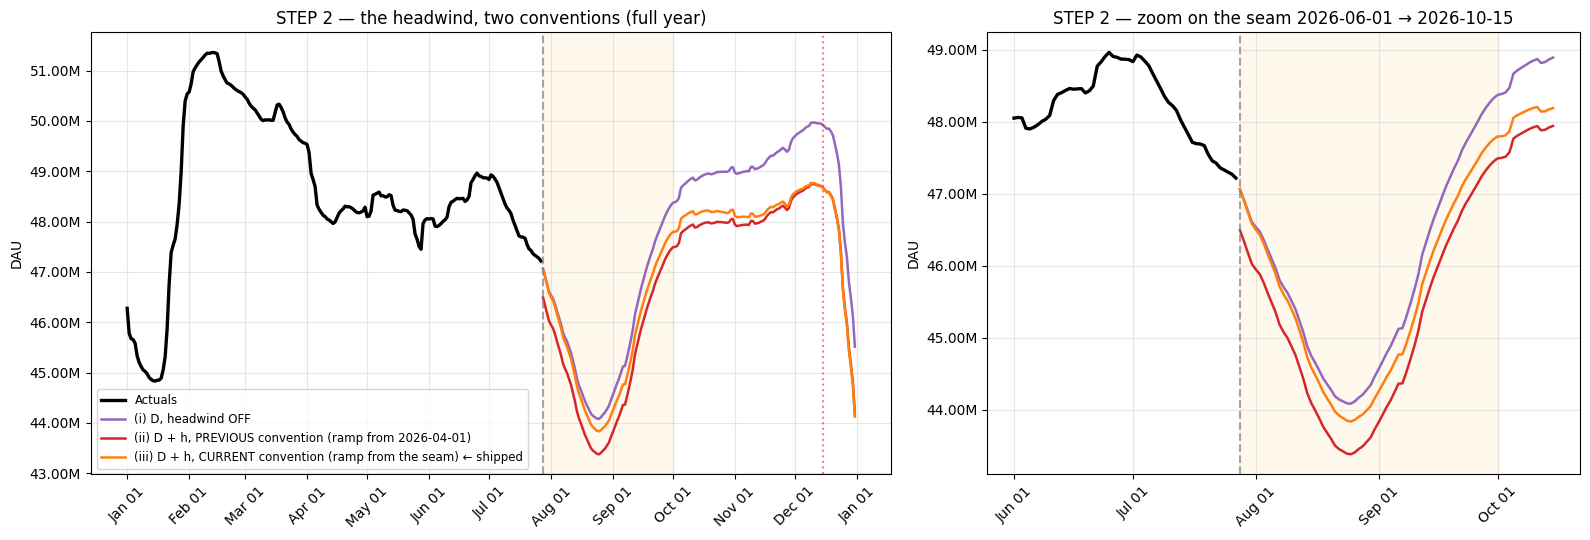

saved: data-official/2026-08/plots/ladder_02b_headwind_ramps.png


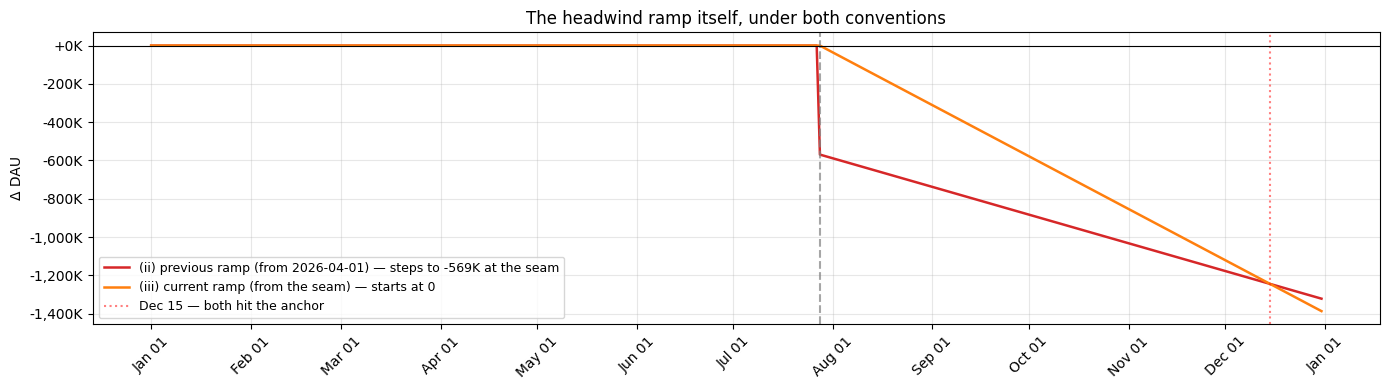

In [7]:
# [plot-headwind-conventions]
# STEP 2 -- the Win10 headwind `h`, the only DISPLAY-LAYER adjustment. It is added to the finished
# 28d-MA of run D, so its effect is exact arithmetic and needs no model re-run.
#
# THIS IS THE PLOT THAT EXPLAINS THE SEAM DROP. Three lines, all from the same run D parquet:
#   (i)   headwind OFF                     -- continuous across the seam
#   (ii)  PREVIOUS convention (superseded 2026-07-29): ramp starts 2026-04-01, switched on at the seam.
#         By the seam it has already accumulated 118/258 = 45.7% of the anchor, so it lands as a
#         LEVEL STEP. This is what produced the discontinuity in the earlier published charts.
#   (iii) CURRENT convention (what headwind.json now specifies): ramp starts at the seam. Reaches the
#         identical Dec-15 anchor, but zero at the seam -- no step, and the whole interior sits higher.
#
# (ii) and (iii) hit the SAME Dec-15 value. They disagree about whether the Apr->Jul portion of the
# Win10 loss is already present in the training actuals. It is: the model was fit on data through
# 2026-07-27. Under (ii) that stretch is charged twice.
hw_applied = headwind_ramp(curves["lo"].index, ramp_start="2026-04-01", applied_from=SEAM)
hw_seam = headwind_ramp(curves["lo"].index, ramp_start=SEAM, applied_from=SEAM)

variants = {
    "off": (curves["lo"], "#9467BD", "(i) D, headwind OFF"),
    "applied": (curves["lo"] + hw_applied, "#D62728",
                "(ii) D + h, PREVIOUS convention (ramp from 2026-04-01)"),
    "seam": (curves["lo"] + hw_seam, "#FF7F0E",
             "(iii) D + h, CURRENT convention (ramp from the seam) ← shipped"),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={"width_ratios": [1.35, 1]})
for ax, (lo_x, hi_x), title in [
    (axes[0], (DISPLAY_START, DISPLAY_END), "STEP 2 — the headwind, two conventions (full year)"),
    (axes[1], ZOOM, f"STEP 2 — zoom on the seam {ZOOM[0].date()} → {ZOOM[1].date()}"),
]:
    ax.plot(clip_to(actual_ma, lo_x, hi_x), color="black", linewidth=2.4, label="Actuals")
    for key, (curve, color, label) in variants.items():
        ax.plot(clip_to(curve, max(lo_x, SEAM), hi_x), color=color, linewidth=1.8, label=label)
    ax.axvline(SEAM, color="grey", linestyle="--", alpha=0.7)
    if hi_x >= MEASUREMENT_DATE:
        ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5)
    ax.axvspan(SEAM, min(OCT1, hi_x), color="orange", alpha=0.07)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("DAU")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)
axes[0].legend(loc="lower left", fontsize=8.5)
plt.tight_layout()
out = f"{PLOTS_DIR}/ladder_02_headwind_conventions.png"
fig.savefig(out, dpi=130); print(f"saved: {out}")
plt.show()

# The ramps themselves, so the mechanism is visible rather than inferred.
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(clip_to(hw_applied, DISPLAY_START, DISPLAY_END), color="#D62728", linewidth=1.8,
        label="(ii) previous ramp (from 2026-04-01) — steps to -569K at the seam")
ax.plot(clip_to(hw_seam, DISPLAY_START, DISPLAY_END), color="#FF7F0E", linewidth=1.8,
        label="(iii) current ramp (from the seam) — starts at 0")
ax.axvline(SEAM, color="grey", linestyle="--", alpha=0.7)
ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15 — both hit the anchor")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("The headwind ramp itself, under both conventions", fontsize=12)
ax.set_ylabel("Δ DAU")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f"{v/1e3:+,.0f}K"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.legend(loc="lower left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
out = f"{PLOTS_DIR}/ladder_02b_headwind_ramps.png"
fig.savefig(out, dpi=130); print(f"saved: {out}")
plt.show()


In [8]:
# [table-headwind]
# Numbers behind STEP 2. The seam-step row is the whole question: how much of the visible drop in the
# published chart is the headwind switching on, rather than anything the model did?
prev = SEAM - pd.Timedelta(days=1)
spec = json.load(open(HEADWIND_SPEC))
anchor_date = pd.Timestamp(spec["anchor_date"])
# What the spec says NOW (seam-anchored since 2026-07-29) vs the superseded April start, so the
# comparison stays legible after the convention flip.
spec_start = pd.Timestamp(spec["start_date"])
OLD_RAMP_START = pd.Timestamp("2026-04-01")
elapsed = (SEAM - OLD_RAMP_START).days
total = (anchor_date - OLD_RAMP_START).days

print(f"Headwind spec NOW: ramp {spec_start.date()} -> {anchor_date.date()}, "
      f"desktop anchor {spec['desktop_dau']:+,}")
print(f"Superseded convention: ramp {OLD_RAMP_START.date()} -> {anchor_date.date()}. At the seam "
      f"{SEAM.date()} it was {elapsed}/{total} = {elapsed/total*100:.1f}% elapsed "
      f"-> {at(hw_applied, SEAM):+,.0f}, applied as a one-day step.\n")

print("SEAM STEP -- change in the 28d-MA from the last training day to the first forecast day")
hdr = f"{'variant':<44s}{str(prev.date()):>14s}{str(SEAM.date()):>14s}{'step':>13s}"
print(hdr); print("-" * len(hdr))
for key, (curve, _c, label) in variants.items():
    print(f"{label:<44s}{at(curve, prev):>14,.0f}{at(curve, SEAM):>14,.0f}"
          f"{at(curve, SEAM)-at(curve, prev):>+13,.0f}")
step_applied = at(variants['applied'][0], SEAM) - at(variants['applied'][0], prev)
print(f"\nUnder the superseded convention the step was {step_applied:+,.0f}; the ramp value at the seam is "
      f"{at(hw_applied, SEAM):+,.0f}.")
print(f"=> the headwind accounts for {at(hw_applied, SEAM)/step_applied*100:.1f}% of the drop. "
      f"A 28-day trailing MA cannot physically move that far in one day; nothing in the model did this.")

print("\nRAMP VALUE AND RESULTING CURVE, BY DATE  (ii = superseded, iii = current/shipped)")
hdr2 = (f"{'date':<12s}{'ramp (ii)':>13s}{'ramp (iii)':>13s}{'lift':>12s}"
        f"{'curve (ii)':>14s}{'curve (iii)':>14s}")
print(hdr2); print("-" * len(hdr2))
for d in [SEAM, TROUGH_DATE, pd.Timestamp("2026-09-01"), OCT1,
          pd.Timestamp("2026-11-01"), MEASUREMENT_DATE]:
    r_a, r_s = at(hw_applied, d), at(hw_seam, d)
    print(f"{str(d.date()):<12s}{r_a:>+13,.0f}{r_s:>+13,.0f}{r_s-r_a:>+12,.0f}"
          f"{at(variants['applied'][0], d):>14,.0f}{at(variants['seam'][0], d):>14,.0f}")

dec_gap = at(variants['seam'][0], MEASUREMENT_DATE) - at(variants['applied'][0], MEASUREMENT_DATE)
print(f"\nDec-15 difference between the two conventions: {dec_gap:+,.0f} "
      f"(should be ~0 -- both ramps terminate on the same anchor).")
assert abs(dec_gap) < 1, (
    f"The two headwind conventions disagree at the Dec-15 anchor by {dec_gap:+,.0f}. They are "
    f"constructed to coincide there; a nonzero gap means the ramp construction is wrong."
)

# Trough under each convention -- the summer-slump number the parameter search would be chasing.
print("\nSUMMER TROUGH (minimum of the forecast portion)")
for key, (curve, _c, label) in variants.items():
    fc = clip_to(curve, SEAM, DISPLAY_END)
    print(f"  {label:<44s}{fc.min():>14,.0f} on {fc.idxmin().date()}")


Headwind spec NOW: ramp 2026-07-28 -> 2026-12-15, desktop anchor -1,245,000
Superseded convention: ramp 2026-04-01 -> 2026-12-15. At the seam 2026-07-28 it was 118/258 = 45.7% elapsed -> -569,419, applied as a one-day step.

SEAM STEP -- change in the 28d-MA from the last training day to the first forecast day
variant                                         2026-07-27    2026-07-28         step
-------------------------------------------------------------------------------------
(i) D, headwind OFF                             47,216,860    47,063,675     -153,185
(ii) D + h, PREVIOUS convention (ramp from 2026-04-01)    47,216,860    46,494,256     -722,604
(iii) D + h, CURRENT convention (ramp from the seam) ← shipped    47,216,860    47,063,675     -153,185

Under the superseded convention the step was -722,604; the ramp value at the seam is -569,419.
=> the headwind accounts for 78.8% of the drop. A 28-day trailing MA cannot physically move that far in one day; nothing in the model 

saved: data-official/2026-08/plots/ladder_03_full.png


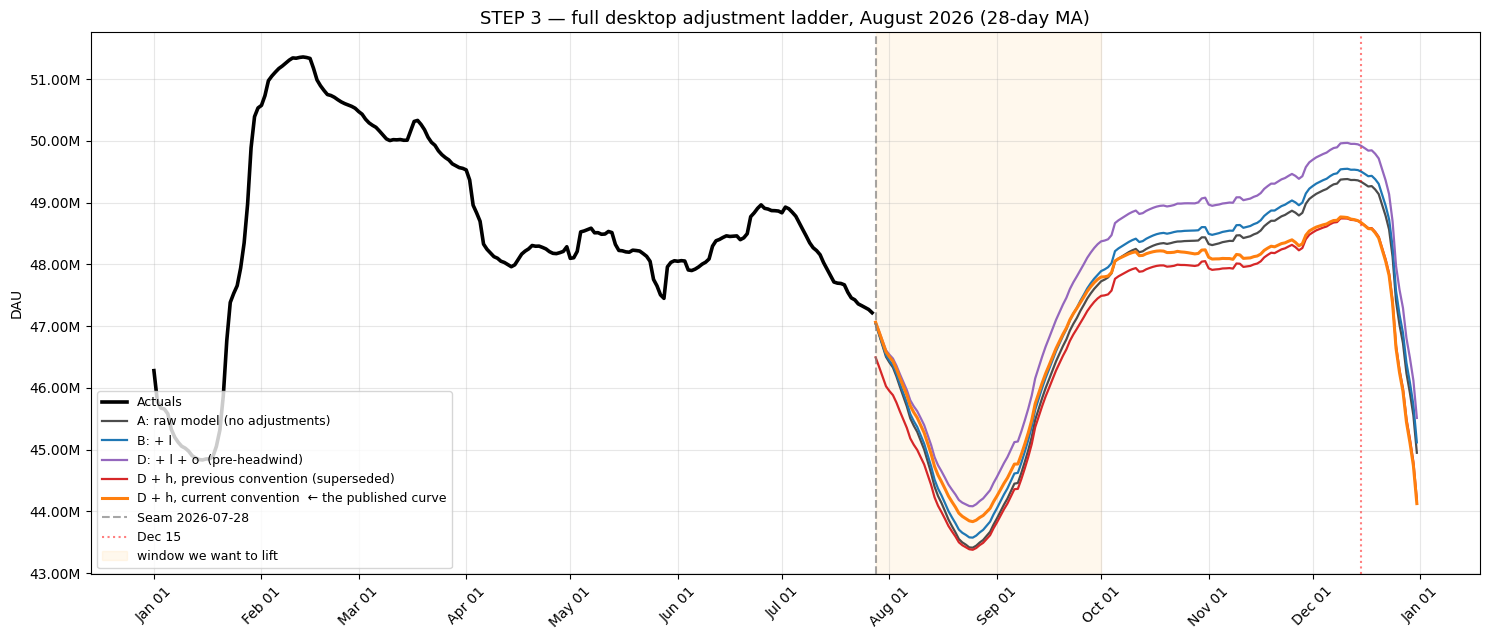

CUMULATIVE LADDER — 28d-MA at each checkpoint date
step                                      2026-07-28    2026-08-22    2026-10-01    2026-12-15
----------------------------------------------------------------------------------------------
A: raw model (no adjustments)             47,036,870    43,497,195    47,726,376    49,335,465
B: + l                                    47,043,161    43,652,940    47,891,518    49,501,653
   (Δ from previous row)                      +6,291      +155,745      +165,142      +166,188
D: + l + o  (pre-headwind)                47,063,675    44,141,035    48,373,593    49,917,970
   (Δ from previous row)                     +20,514      +488,095      +482,075      +416,317
D + h, previous convention (superseded)    46,494,256    43,450,977    47,490,512    48,672,970
   (Δ from previous row)                    -569,419      -690,058      -883,081    -1,245,000
D + h, current convention  ← the published curve    47,063,675    43,918,713    47,795,557   

In [9]:
# [plot-full-ladder]
# STEP 3 -- everything on one chart, accumulated in the order the pipeline applies it. Reading top to
# bottom at any date tells you what each adjustment is contributing there.
#
# The last line (D + h, current convention) is what the published August chart shows. The row above
# it is the superseded convention, kept so the seam step it produced stays visible.
ladder = [
    (curves["none"],                "#4C4C4C", "A: raw model (no adjustments)"),
    (curves["l"],                   "#1F77B4", "B: + l"),
    (curves["lo"],                  "#9467BD", "D: + l + o  (pre-headwind)"),
    (curves["lo"] + hw_applied,     "#D62728", "D + h, previous convention (superseded)"),
    (curves["lo"] + hw_seam,        "#FF7F0E", "D + h, current convention  ← the published curve"),
]

fig, ax = plt.subplots(figsize=(15, 6.5))
ax.plot(clip_to(actual_ma, DISPLAY_START, DISPLAY_END), color="black", linewidth=2.6, label="Actuals")
for curve, color, label in ladder:
    lw = 2.2 if "published" in label else 1.6
    ax.plot(clip_to(curve, SEAM, DISPLAY_END), color=color, linewidth=lw, label=label)
ax.axvline(SEAM, color="grey", linestyle="--", alpha=0.7, label=f"Seam {SEAM.date()}")
ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
ax.axvspan(SEAM, OCT1, color="orange", alpha=0.07, label="window we want to lift")
ax.set_title("STEP 3 — full desktop adjustment ladder, August 2026 (28-day MA)", fontsize=13)
ax.set_ylabel("DAU")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.legend(loc="lower left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
out = f"{PLOTS_DIR}/ladder_03_full.png"
fig.savefig(out, dpi=130); print(f"saved: {out}")
plt.show()

print("CUMULATIVE LADDER — 28d-MA at each checkpoint date")
dates = [SEAM, TROUGH_DATE, OCT1, MEASUREMENT_DATE]
hdr = f"{'step':<38s}" + "".join(f"{str(d.date()):>14s}" for d in dates)
print(hdr); print("-" * len(hdr))
prev_vals = None
for curve, _c, label in ladder:
    vals = [at(curve, d) for d in dates]
    line = f"{label:<38s}" + "".join(f"{v:>14,.0f}" for v in vals)
    print(line)
    if prev_vals is not None:
        delta = f"{'   (Δ from previous row)':<38s}" + "".join(
            f"{v - p:>+14,.0f}" for v, p in zip(vals, prev_vals))
        print(delta)
    prev_vals = vals


## How to read this, and what it means for the parameter search

### The seam drop is not the model's

Run A — no overlays, no headwind — is continuous across the seam, and so are B, C and D. The step in the
published chart appears only when `h` is added under the **as-applied** convention, because the ramp
starts 2026-04-01 and is switched on at 2026-07-28, by which point it has already accumulated 45.7% of
the anchor. A 28-day trailing MA cannot move that far in a single day; the discontinuity is arithmetic
from the display layer, not a forecast behaviour.

**No parameter value can change this.** `changepoint_prior_scale`, `changepoint_range`,
`seasonality_prior_scale` and the rest all act inside the model, and the model is already continuous
there. Tuning them will move the depth and shape of the trough; it cannot remove the step.

### The two conventions — RESOLVED 2026-07-29, seam-anchored shipped

Both reach the identical Dec-15 anchor. They differ on one factual question: **is the April→July Win10
loss already in the training data?**

- **Previous (ramp from 2026-04-01)** implicitly says no — it charges the elapsed portion again at the seam.
- **Current (ramp from the seam)** says yes — it charges only the loss still to come.

The model was fit on data through 2026-07-27, so any attrition that actually happened in that window is
in the fitted level already. That argues for seam-anchoring. It is also the same premise used to justify
attenuating the anchor four times this year ("Prophet has learned more of the decline") — so the previous
setup asserted that premise through one channel while contradicting it through another, which is
plausibly part of why the anchor kept needing to come down.

**Decision:** `data-official/2026-08/adjustments/headwind.json` now has `start_date: "2026-07-28"`.
Desktop Dec-15 is unchanged at 48,672,970; the Aug-22 trough went 43,453,752 → 43,921,488. Mobile was
re-anchored too (one `start_date` serves both platforms): its seam step went from −12,424 to 0 and its
Dec-15 is likewise unchanged. `l` and `o` were not touched.

Two things this leaves open:

- **Cross-cycle comparability.** June's and July's specs are untouched, so the prior line still
  reproduces July's delivered Dec-15 exactly — but between the seam and Dec-15 the two cycles are now on
  different conventions and should not be compared point-for-point there.
- **Post-anchor overshoot.** Three of the four ramp implementations don't clamp at the anchor
  (`src/mozaic_daily/adjustments.py`, the canonical notebook's helper,
  `data-official/2026-06/export_canonical_curves.py`); `scripts/score_near_horizon.py` does. Seam
  anchoring shortens the ramp from 258 to 140 days, so it is steeper and the unclamped overshoot at
  2026-12-31 grows from ≈−1,322,000 to ≈−1,387,000. Cosmetic for a Dec-15 KPI and it touches no reported
  number, but it is a genuine inconsistency between implementations. **Not fixed here.**

### What this means for the parameter search

The convention change has already banked +467,737 at Aug-22 for free, holding the KPI by construction.
**Any parameter search should now be calibrated against the post-re-anchoring baseline**, not the numbers
in the earlier August builds — the target has moved.

For contrast on what parameters can contribute, July's three-round search over this same problem
(`research/param-scans/aug22-retune/`) concluded that **no exposed parameter combination raises the summer
trough while holding Dec-15**: `cps` and `recent_weeks` are inert (±≤40K), `n_changepoints` weak (+37K),
`changepoint_range` the only live trend lever (±100–115K), and the one strong lever —
`seasonality_prior_scale` — trades summer against December at roughly 1:1.4, so buying the trough breaks
the KPI. Its recommendation was a dedicated summer-trough overlay, not a parameter fix.

So the realistic remaining options for further summer lift are a bidirectional summer-trough overlay (the
`aug22-retune` recommendation, still awaiting a go/no-go) or accepting the current shape — not parameter
tuning. Note also that the seam step is gone, so the *discontinuity* half of the original problem is
solved and only the trough *depth* remains.

### Reproducing the four runs

```bash
source .venv/bin/activate
CACHE=data-official/2026-08/desktop_baseline_2026-07-28/cps0.08983_thresh032_recent13_cpr0.65_ncp25_clip0.6_sps0.00825
# repeat with --no-launch-on-login / --no-mozillaonline / both, one --results-dir each
python3 scripts/run_param_scan.py --forecast-start-date 2026-07-28 \
    --changepoint-prior-scale 0.08983 --changepoint-range 0.65 --n-changepoints 25 --recent-weeks 13 \
    --holiday-threshold -0.032 --holiday-max-radius 5 --holiday-min-radius 3 \
    --holiday-effect-floor -0.6 --raw-cache-dir "$CACHE" \
    --no-launch-on-login --no-mozillaonline \
    --results-dir data-official/2026-08/adjustment_isolation/none
```

The `--no-launch-on-login` / `--no-mozillaonline` toggles were added to `run_param_scan.py` for this
notebook; they suppress an overlay even when its spec matches and leave the suppressed code off the
filename marker, so each parquet's name always states what is actually baked into it. Passing
`--raw-cache-dir` reuses the already-fetched BQ aggregate, so none of these runs re-queried BigQuery.
